# Neural Collaborative Filtering (NCF)


In [1]:
# import libraries
import pandas as pd 
import numpy as np 
import pickle 
import os
import json
import warnings
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import dataloader, Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt

from tqdm import tqdm
warnings.filterwarnings("ignore")

print("Libraries loaded.")
print(f"Run started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries loaded.
Run started: 2026-04-12 00:13:57


In [2]:
#Getting the project root path 
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, "data")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")
MODELS_DIR = os.path.join(os.path.join(BASE_DIR, "models"))

plots_dir = os.path.join(PROCESSED_DATA_DIR, "plots")
os.makedirs(plots_dir, exist_ok=True)

print(f"Base directory: {BASE_DIR}")

Base directory: c:\Projects\Cinemate V2


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)
print(f"Pytorch version : {torch.__version__}")

cuda
Pytorch version : 2.7.1+cu118


In [5]:
#Load processed directories
print("Loading preprocessed file...............")


train = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "train.parquet"))
test = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "test.parquet"))
movies_clean = pd.read_parquet(os.path.join(PROCESSED_DATA_DIR, "movies_clean.parquet"))

with open(os.path.join(PROCESSED_DATA_DIR, "dataset_constants.pkl"), "rb") as f:
    constants = pickle.load(f)

NUM_USERS = constants["NUM_USERS"]
NUM_MOVIES = constants["NUM_MOVIES"]

with open(os.path.join(PROCESSED_DATA_DIR, "user_positive_sets.pkl") , "rb") as f:
    user_positive_sets = pickle.load(f)

with open(os.path.join(PROCESSED_DATA_DIR, "encoders/idx2movie.pkl"), "rb") as f:
    idx2movie = pickle.load(f)

with open(os.path.join(PROCESSED_DATA_DIR, "encoders/idx2user.pkl"), 'rb') as f:
    idx2user = pickle.load(f)

print(f"Train ratings: {len(train)}")
print(f"Test ratings : {len(test)}")
print(f"Num Users : {NUM_USERS}")
print(f"Num Movies : {NUM_MOVIES}")


Loading preprocessed file...............
Train ratings: 25868311
Test ratings : 795563
Num Users : 173134
Num Movies : 27766


### NCF vs SVD — What Changes

SVD predicts a rating as:
    r̂(u, i) = μ + b_u + b_i + p_u · q_i

Where p_u · q_i is a simple dot product (linear).

NCF replaces the dot product with an MLP:
    r̂(u, i) = MLP([p_u ; q_i])

The MLP can learn:
- Non-linear interactions between user and item
- Higher-order feature crosses
- Complex preference patterns SVD cannot represent

Example SVD cannot capture:

User A likes Sci-Fi AND Comedy but NOT Sci-Fi comedies.

SVD: linear → cannot model this exclusion

NCF: MLP → can learn this non-linear boundary

In [ ]:
# class NCFDataset(Dataset):
#     """
#     Returns BPR triplets:
#     (user_idx, positive_movie_idx, negative_movie_idx)

#     Identical to TwoTowerDataset but named separately
#     for clarity — NCF uses ONLY these indices,
#     no content features.
#     """
#     def __init__(self, ratings_df, user_positive_sets, num_movies, positive_threshold =3.5, neg_sample_tries = 5):
#         self.num_movies = num_movies
#         self.user_positive_sets =user_positive_sets
#         self.neg_sample_tries = neg_sample_tries

#         positive_df= ratings_df[ratings_df["rating"]>=positive_threshold].copy()

#         self.users  = positive_df['user_idx'].values.astype(np.int32)
#         self.movies = positive_df['movie_idx'].values.astype(np.int32)

#         print(f"NCF Dataset size       : {len(self.users)} triplets")
#         print(f"Positive threshold     : >= {positive_threshold}")    

    # def __len__(self):
    #     return len(self.users)
    
#     def __getitem__(self, idx):
#         user_idx= int(self.users[idx])
#         pos_movie = int(self.movies[idx])
#         seen_movies = self.user_positive_sets.get(user_idx, set())

#         neg_movie = np.random.randint(0, self.num_movies)
#         for _ in range(10):
#             if neg_movie not in seen_movies:
#                 break
#             neg_movie = np.random.randint(0, self.num_movies)

#         return {
#             "user_idx" : torch.tensor(user_idx,   dtype=torch.long),
#             "pos_movie": torch.tensor(pos_movie,  dtype=torch.long),
#             "neg_movie": torch.tensor(neg_movie, dtype=torch.long)
#         }

# BATCH_SIZE = 2048
# train_dataset =NCFDataset(ratings_df=train,
#                           user_positive_sets=user_positive_sets,
#                           num_movies=NUM_MOVIES,
#                           positive_threshold=3.5)

# train_loader = DataLoader(train_dataset, 
#                           batch_size=BATCH_SIZE,
#                           shuffle=True,
#                           num_workers=6,
#                           pin_memory=True if DEVICE.type == 'cuda' else False,
#                           persistent_workers=True    #Workers stay alive between epochs, Workers restart every epoch 
#                           )

# print(f"\nBatch size    : {BATCH_SIZE:,}")
# print(f"Batches/epoch : {len(train_loader):,}")

In [8]:
class NCFDataset(Dataset):
    def __init__(self, ratings_df, user_positive_sets, num_movies,
                 positive_threshold=3.5, neg_sample_tries=10,
                 use_tail_sampling=True, p_tail=0.4):
        self.num_movies         = num_movies
        self.user_positive_sets = user_positive_sets
        self.neg_sample_tries   = neg_sample_tries
        self.p_tail             = p_tail

        positive_df = ratings_df[
            ratings_df["rating"] >= positive_threshold
        ].copy()

        self.users  = positive_df['user_idx'].values.astype(np.int32)
        self.movies = positive_df['movie_idx'].values.astype(np.int32)

        self.tail_movies = None
        if use_tail_sampling:
            movie_counts     = ratings_df.groupby('movie_idx').size()
            threshold        = movie_counts.quantile(0.70)
            tail_idxs        = movie_counts[
                movie_counts <= threshold
            ].index.values
            self.tail_movies = tail_idxs
            print(f"NCF Dataset size              : {len(self.users):,}")
            print(f"Positive threshold            : >= {positive_threshold}")
            print(f"Tail movies (≤70th pct pop)   : {len(self.tail_movies):,}")
            print(f"Tail sampling probability     : {p_tail}")
        else:
            print(f"NCF Dataset size       : {len(self.users):,} triplets")
            print(f"Positive threshold     : >= {positive_threshold}")

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        user_idx    = int(self.users[idx])
        pos_movie   = int(self.movies[idx])
        seen_movies = self.user_positive_sets.get(user_idx, set())

        def sample_neg():
            if (self.tail_movies is not None
                    and np.random.random() < self.p_tail):
                return int(np.random.choice(self.tail_movies))
            return np.random.randint(0, self.num_movies)

        neg_movie = sample_neg()
        for _ in range(self.neg_sample_tries):
            if neg_movie not in seen_movies:
                break
            neg_movie = sample_neg()

        return {
            "user_idx"  : torch.tensor(user_idx,  dtype=torch.long),
            "pos_movie" : torch.tensor(pos_movie, dtype=torch.long),
            "neg_movie" : torch.tensor(neg_movie, dtype=torch.long)
        }

BATCH_SIZE    = 2048
train_dataset = NCFDataset(
    ratings_df         = train,
    user_positive_sets = user_positive_sets,
    num_movies         = NUM_MOVIES,
    positive_threshold = 3.5,
    use_tail_sampling  = True,   
    p_tail             = 0.4     
)

train_loader = DataLoader(train_dataset, 
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=6,
                          pin_memory=True if DEVICE.type == 'cuda' else False,
                          persistent_workers=True    #Workers stay alive between epochs, Workers restart every epoch 
                          )

print(f"\nBatch size    : {BATCH_SIZE:,}")
print(f"Batches/epoch : {len(train_loader):,}")

NCF Dataset size              : 16,093,850
Positive threshold            : >= 3.5
Tail movies (≤70th pct pop)   : 19,445
Tail sampling probability     : 0.4

Batch size    : 2,048
Batches/epoch : 7,859


### NCF Model

In [9]:
class NCFModel(nn.Module):
    def __init__(self,num_users, num_movies, embed_dim = 64, dropout = 0.2):
        super().__init__()

        self.user_embeddings = nn.Embedding(num_users, embed_dim)   # matrix --> (num_users × embed_dim) --> 173,000 users × 64 dimensions.
        self.movie_embeddings = nn.Embedding(num_movies, embed_dim)

        # MLP — learns non-linear interactions
        # Input: concat of user + movie embedding = embed_dim * 2
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim*2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

        #Weight normalisation
        nn.init.normal_(self.user_embeddings.weight, std=0.01)
        nn.init.normal_(self.movie_embeddings.weight, std=0.01)

    def forward(self, user_idx, movie_idx):
        u = self.user_embeddings(user_idx)
        m = self.movie_embeddings(movie_idx)
        x = torch.cat([u, m], dim=-1)
        return self.mlp(x).squeeze(-1)  
    
#Instantiate
model = NCFModel(num_users=NUM_USERS,
                 num_movies=NUM_MOVIES,
                 embed_dim=64,
                 dropout=0.2).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("NCF Model instantiated.")
print()
print("Architecture:")
print(f"  user_embedding  : ({NUM_USERS:,}, 64)")
print(f"  movie_embedding : ({NUM_MOVIES:,}, 64)")
print(f"  MLP input       : 128 → 256 → 128 → 64 → 32 → 1")
print(f"  Output          : relevance score (0–1)")
print()
print(f"Total trainable params : {total_params:,}")
print()
print("Key difference from SVD:")
print("  SVD  → dot product (linear)")
print("  NCF  → MLP (non-linear, can learn complex patterns)")
        

NCF Model instantiated.

Architecture:
  user_embedding  : (173,134, 64)
  movie_embedding : (27,766, 64)
  MLP input       : 128 → 256 → 128 → 64 → 32 → 1
  Output          : relevance score (0–1)

Total trainable params : 12,933,889

Key difference from SVD:
  SVD  → dot product (linear)
  NCF  → MLP (non-linear, can learn complex patterns)


In [10]:
## BPR Loss
def bpr_loss(pos_score, neg_score):
    """
    BPR: positive movie should score higher than negative.
    Loss = -mean(log(sigmoid(pos - neg)))
    """
    return -torch.log(torch.sigmoid(pos_score - neg_score) + 1e-8).mean()

# Sanity checks
pos = torch.tensor([0.8, 0.9, 0.7])
neg = torch.tensor([0.2, 0.1, 0.3])
print(f"BPR loss (pos > neg) : {bpr_loss(pos, neg):.4f}  ← should be low")

pos_bad = torch.tensor([0.2, 0.1, 0.3])
neg_bad = torch.tensor([0.8, 0.9, 0.7])
print(f"BPR loss (neg > pos) : {bpr_loss(pos_bad, neg_bad):.4f}  ← should be high")

BPR loss (pos > neg) : 0.4405  ← should be low
BPR loss (neg > pos) : 1.0405  ← should be high


In [11]:
#Training configuaration
EPOCHS = 27
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5

optimizer = Adam(model.parameters(),    #this is what update weights
                 lr = LEARNING_RATE,
                 weight_decay=WEIGHT_DECAY)

scheduler = ReduceLROnPlateau(optimizer=optimizer,         #Automatically reduces learning rate when model stops improving
                              mode="min",       #monitor loss → want it to decrease
                              patience=3,       #wait 3 epochs without improvement
                              factor=0.5,       #reduce LR by half
                              min_lr=1e-5)      # don’t go below this

print("Training config:")
print(f"  Epochs        : {EPOCHS}")
print(f"  Learning rate : {LEARNING_RATE}")
print(f"  Weight decay  : {WEIGHT_DECAY}")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Loss          : BPR")
print(f"  Device        : {DEVICE}")

Training config:
  Epochs        : 27
  Learning rate : 0.001
  Weight decay  : 1e-05
  Batch size    : 2048
  Loss          : BPR
  Device        : cuda


In [12]:
# #Training loop 
# def train_one_epoch(model, loader, optimizer, device):
#     model.train()          #set training mode
#     total_loss =0.0
#     total_batch = 0

#     for batch in loader:             #Each batch contain 2048 (user, pos, neg) triplets
#         user_idx = batch['user_idx'].to(device, non_blocking=True)  #model is on GPU , data must also be on GPU
#         pos_movie = batch['pos_movie'].to(device, non_blocking=True)
#         neg_movie = batch['neg_movie'].to(device, non_blocking=True)

#         pos_score = model(user_idx, pos_movie)
#         neg_score = model(user_idx, neg_movie)

#         loss = bpr_loss(pos_score, neg_score)

#         optimizer.zero_grad()
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()

#         total_loss += loss.item()
#         total_batch += 1
#     return total_loss / total_batch

# history = {"train_loss": [], "epoch_time":[]}

# best_loss = float("inf")
# best_model_path = os.path.join(MODELS_DIR, "ncf_best.pkl")

# print("Starting NCF Training..........")
# print("="* 70)

# for epoch in tqdm(range(1, EPOCHS+1)):
#     start = datetime.now()
#     avg_loss = train_one_epoch(
#         model, train_loader, optimizer, DEVICE
#     )
#     epoch_time = (datetime.now() -start).seconds

#     history['train_loss'].append(avg_loss)
#     history['epoch_time'].append(epoch_time)

#     scheduler.step(avg_loss)      #if loss stop improving reduce learning rate

#     if avg_loss < best_loss:
#         best_loss = avg_loss
#         torch.save({"epoch": epoch,
#                     "model_state": model.state_dict(),
#                     "optim_state": optimizer.state_dict(),
#                     "loss": best_loss,
#                     "NUM_USERS": NUM_USERS,
#                     "NUM_MOVIES": NUM_MOVIES
#                     }, best_model_path)
#         marker = " ← best"
#     else: 
#         marker = ""

#     print(f"Epoch {epoch}/{EPOCHS}    |"
#           f"Loss  {avg_loss:.4f}        |"
#           f"Time  {epoch_time}s{marker}")   

# print()
# print(f"Best loss      : {best_loss:.4f}")
# print(f"Model saved to : {best_model_path}")




In [24]:
history_path = os.path.join(MODELS_DIR, "ncf_training_history.csv")
history = pd.read_csv(history_path)
history = history.to_dict(orient="list")

# Convert back to original format
# history = {
#     "train_loss": history_df["train_loss"].tolist(),
#     "epoch_time": history_df["epoch_time_sec"].tolist()
# }

print("History loaded successfully")
print(history)

History loaded successfully
{'train_loss': [0.0784733466991737, 0.0665544050549305, 0.0595288432154291, 0.0557785362696348, 0.0542010262080948, 0.0534458100408948, 0.0531377406068689, 0.0527945558643265, 0.0527654757787441, 0.0524239999447494, 0.0522891209600748, 0.0522798303240263, 0.0520200404304291, 0.0518900715563607, 0.051793240540451, 0.0516333087142554, 0.0515312537973274, 0.0514383267927433, 0.0513158209364989, 0.0512559415843896, 0.0511675694082105, 0.0510300777106908, 0.0508926294789994, 0.0507625845524115, 0.0507129917068439, 0.050666232054757, 0.0505651953728626], 'epoch_time': [303, 317, 326, 328, 327, 328, 323, 323, 323, 324, 323, 321, 321, 302, 315, 315, 303, 323, 324, 324, 325, 320, 320, 321, 323, 326, 327]}


In [25]:
# ── Save popularity lookup for inference ──────────────────
# This is used by recommend.py debias pipeline
# Must be saved from training notebook where train data exists

# from src.debias import build_popularity_lookup

lookup_path = os.path.join(
    MODELS_DIR, "popularity_lookup.npy"
)

# popularity_lookup = build_popularity_lookup(
#     train_df   = train,
#     num_movies = NUM_MOVIES,
#     save_path  = lookup_path
# )
popularity_lookup = np.load(lookup_path)

print(f"Popularity lookup saved : {lookup_path}")
print(f"Shape                   : {popularity_lookup.shape}")
print(f"Mean popularity score   : {popularity_lookup.mean():.4f}")
print(f"Movies with 0 ratings   : "
      f"{(popularity_lookup == 0).sum():,}")

Popularity lookup saved : c:\Projects\Cinemate V2\models\popularity_lookup.npy
Shape                   : (27766,)
Mean popularity score   : 0.3687
Movies with 0 ratings   : 0


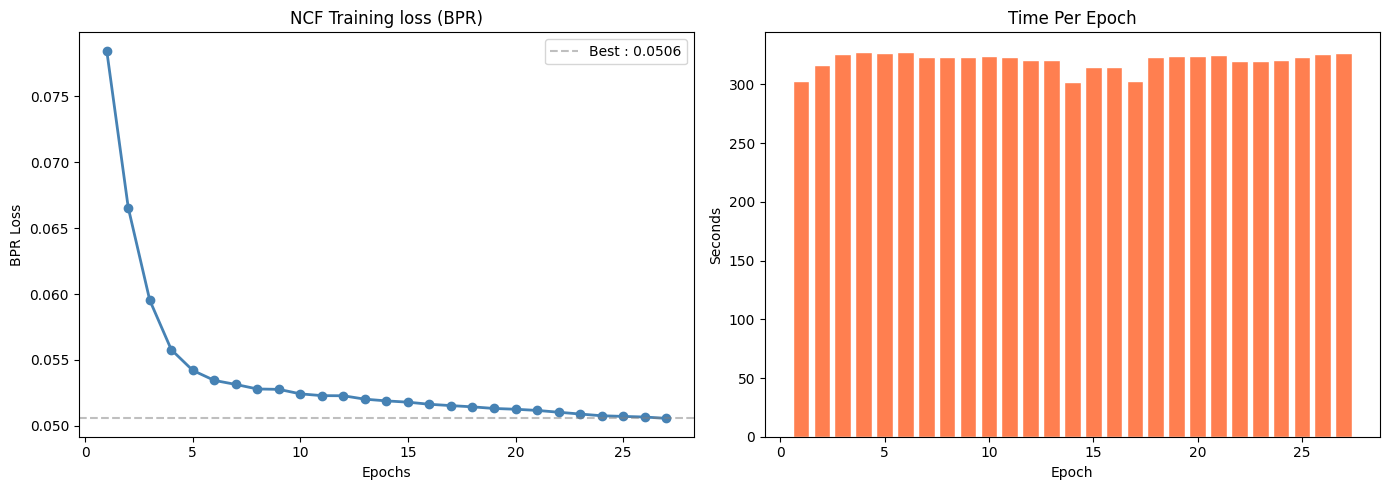

Total training time : 8655s


In [26]:
#Plot training loss 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS +1), history['train_loss'], color = "steelblue", marker="o", linewidth=2)
axes[0].set_title("NCF Training loss (BPR)")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("BPR Loss")
axes[0].axhline(y=min(history['train_loss']), color="gray", linestyle="--", alpha = 0.5, label=f"Best : {min(history['train_loss']):.4f}")
axes[0].legend()

axes[1].bar(range(1, EPOCHS+1),
            history['epoch_time'],
            color='coral', edgecolor='white')
axes[1].set_title('Time Per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Seconds')

plt.tight_layout()


plt.savefig(os.path.join(plots_dir, "08_ncf_training_loss.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Total training time : {sum(history['epoch_time'])}s")



In [27]:
#Evaluation Functions
def ndcg_at_k(recommended, relevant_set, k=10):
    dcg  = sum(
        1.0 / np.log2(i + 2)
        for i, m in enumerate(recommended[:k])
        if m in relevant_set
    )
    idcg = sum(
        1.0 / np.log2(i + 2)
        for i in range(min(k, len(relevant_set)))
    )
    return dcg / idcg if idcg > 0 else 0.0


def precision_at_k(recommended, relevant_set, k=10):
    hits = len(set(recommended[:k]) & relevant_set)    #Out of top K recommended, how many were correct?
    return hits / k


def recall_at_k(recommended, relevant_set, k=10):
    if not relevant_set:
        return 0.0
    hits = len(set(recommended[:k]) & relevant_set)   #Out of all relevant movies, how many did we recommend?
    return hits / len(relevant_set)


def evaluate_model(model, eval_users, test_relevant,
                   user_positive_sets, num_movies,
                   device, k=10):
    model.eval()
    all_movies = torch.arange(num_movies).to(device)   #We will score EVERY movie for a user

    ndcg_scores = []
    prec_scores = []
    rec_scores  = []

    with torch.no_grad():   #disable gradient, no training here, faster and less memory
        for user_idx in tqdm(eval_users, desc="Evaluating"):
            relevant = test_relevant.get(user_idx, set())   #Movies user actually liked in test set
            if not relevant:
                continue

            seen = user_positive_sets.get(user_idx, set())   

            u_tensor = torch.tensor(      
                [user_idx] * num_movies,
                dtype=torch.long
            ).to(device)                #user_idx = 10, u_tensor = [10, 10, 10, 10, ..., 10]  (length = num_movies)

            scores = model(u_tensor, all_movies).cpu().numpy()   #output [num_movies scores] --> Meaning: “How much user likes each movie”

            for m in seen:
                if m < len(scores):
                    scores[m] = -np.inf

            top_k = np.argsort(scores)[::-1][:k].tolist()

            ndcg_scores.append(ndcg_at_k(top_k, relevant, k))
            prec_scores.append(precision_at_k(top_k, relevant, k))
            rec_scores.append(recall_at_k(top_k, relevant, k))

    return {
        f'NDCG@{k}'     : float(np.mean(ndcg_scores)),
        f'Precision@{k}': float(np.mean(prec_scores)),
        f'Recall@{k}'   : float(np.mean(rec_scores)),
        'n_users_eval'  : len(ndcg_scores)
    }


print("Evaluation functions defined.")

Evaluation functions defined.


In [28]:
# Load best checkpoint

best_model_path = os.path.join(MODELS_DIR, "ncf_best.pkl")

checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded best checkpoint — epoch {checkpoint['epoch']}")
print()

# Build test relevant sets
test_relevant = (
    test[test['rating'] >= 3.5]
    .groupby('user_idx')['movie_idx']
    .apply(set)
    .to_dict()
)

eval_users  = [u for u, r in test_relevant.items() if len(r) > 0]
N_EVAL      = min(2000, len(eval_users))
eval_sample = eval_users[:N_EVAL]

print(f"Evaluating on {N_EVAL:,} users...")

ncf_results = evaluate_model(
    model              = model,
    eval_users         = eval_sample,
    test_relevant      = test_relevant,
    user_positive_sets = user_positive_sets,
    num_movies         = NUM_MOVIES,
    device             = DEVICE,
    k                  = 10
)

print("\nNCF Results:")
for metric, value in ncf_results.items():
    if metric != 'n_users_eval':
        print(f"  {metric:<15s}: {value:.4f}")
print(f"  Users evaluated : {ncf_results['n_users_eval']:,}")

Loaded best checkpoint — epoch 27

Evaluating on 2,000 users...


Evaluating: 100%|██████████| 2000/2000 [00:21<00:00, 94.85it/s] 


NCF Results:
  NDCG@10        : 0.1252
  Precision@10   : 0.1135
  Recall@10      : 0.0283
  Users evaluated : 2,000


In [29]:
with open(os.path.join(MODELS_DIR, "svd_baseline_results.json"), "r") as f:
    svd_results = json.load(f)
    

random_ndcg = svd_results['metrics']['random']['NDCG@10']
pop_ndcg    = svd_results['metrics']['popularity']['NDCG@10']
svd_ndcg    = svd_results['metrics']['svd']['NDCG@10']
ncf_ndcg    = ncf_results['NDCG@10']

random_prec = svd_results['metrics']['random']['Precision@10']
pop_prec    = svd_results['metrics']['popularity']['Precision@10']
svd_prec    = svd_results['metrics']['svd']['Precision@10']
ncf_prec    = ncf_results['Precision@10']

random_rec  = svd_results['metrics']['random']['Recall@10']
pop_rec     = svd_results['metrics']['popularity']['Recall@10']
svd_rec     = svd_results['metrics']['svd']['Recall@10']
ncf_rec     = ncf_results['Recall@10']

print("=" * 65)
print("RESULTS COMPARISON — SVD vs NCF")
print("=" * 65)
print()
print(f"{'Model':<18s} {'NDCG@10':>10s} "
      f"{'Precision@10':>14s} {'Recall@10':>11s}")
print("-" * 58)
print(f"{'Random':<18s} {random_ndcg:>10.4f} "
      f"{random_prec:>14.4f} {random_rec:>11.4f}")
print(f"{'Popularity':<18s} {pop_ndcg:>10.4f} "
      f"{pop_prec:>14.4f} {pop_rec:>11.4f}")
print(f"{'SVD':<18s} {svd_ndcg:>10.4f} "
      f"{svd_prec:>14.4f} {svd_rec:>11.4f}")
print(f"{'NCF (ours)':<18s} {ncf_ndcg:>10.4f} "
      f"{ncf_prec:>14.4f} {ncf_rec:>11.4f}")
print()

vs_svd = 100 * (ncf_ndcg - svd_ndcg) / svd_ndcg
print(f"NCF vs SVD improvement : {vs_svd:.1f}% NDCG@10")
print()

target = "✓ MET" if ncf_ndcg > svd_ndcg * 1.10 else "✗ NOT MET"
print(f"10% improvement target : {target}")
print()
print("Next step: 05_two_tower.ipynb")
print(f"  NCF gives us  NDCG@10 = {ncf_ndcg:.4f} (collab only)")
print(f"  Two-Tower must beat   > {ncf_ndcg:.4f} (collab + content)")
print(f"  The gap will show exactly what content tower adds.")

RESULTS COMPARISON — SVD vs NCF

Model                 NDCG@10   Precision@10   Recall@10
----------------------------------------------------------
Random                 0.0019         0.0018      0.0004
Popularity             0.0845         0.0749      0.0225
SVD                    0.0669         0.0607      0.0221
NCF (ours)             0.1252         0.1135      0.0283

NCF vs SVD improvement : 87.2% NDCG@10

10% improvement target : ✓ MET

Next step: 05_two_tower.ipynb
  NCF gives us  NDCG@10 = 0.1252 (collab only)
  Two-Tower must beat   > 0.1252 (collab + content)
  The gap will show exactly what content tower adds.


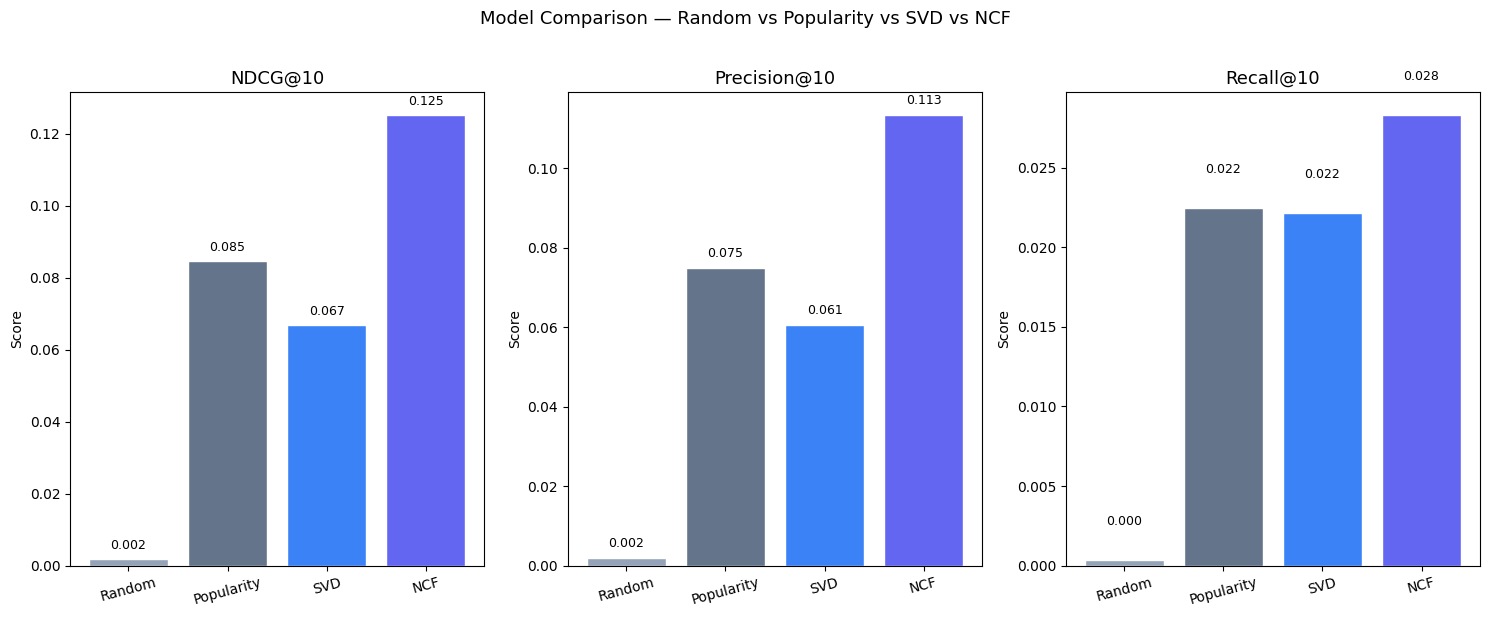

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

models    = ['Random', 'Popularity', 'SVD', 'NCF']
ndcg_vals = [random_ndcg, pop_ndcg, svd_ndcg, ncf_ndcg]
prec_vals = [random_prec, pop_prec, svd_prec, ncf_prec]
rec_vals  = [random_rec,  pop_rec,  svd_rec,  ncf_rec]
colors    = ['#94A3B8', '#64748B', '#3B82F6', '#6366F1']

for ax, vals, title in zip(
    axes,
    [ndcg_vals, prec_vals, rec_vals],
    ['NDCG@10', 'Precision@10', 'Recall@10']
):
    bars = ax.bar(models, vals,
                  color=colors, edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=9
        )

plt.suptitle('Model Comparison — Random vs Popularity vs SVD vs NCF',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(
    os.path.join(plots_dir, "09_ncf_comparison.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()

In [31]:
ncf_summary = {
    "model"      : "NCF",
    "architecture": {
        "embed_dim" : 64,
        "mlp_layers": [256, 128, 64, 32, 1],
        "dropout"   : 0.2,
    },
    "training"   : {
        "epochs"       : EPOCHS,
        "batch_size"   : BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "loss"         : "BPR",
        "best_loss"    : min(history['train_loss']),
        "history"      : history,
    },
    "metrics"    : ncf_results,
    "vs_svd_pct" : round(vs_svd, 2),
    "timestamp"  : datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

path = os.path.join(MODELS_DIR, "ncf_results.json")
with open(path, "w") as f:
    json.dump(ncf_summary, f, indent=2)

print(f"NCF results saved to {path}")

NCF results saved to c:\Projects\Cinemate V2\models\ncf_results.json
